In [1]:
import sys
sys.path.append("../src")

import GOenrichment as ge
import importlib

importlib.reload(ge)

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv"
}



In [ ]:
for subtype, file in files.items():
    ge.analyze_subtype(
        file,
        subtype,
        direction="split"
    )

In [ ]:
for subtype, file in files.items():
    ge.analyze_subtype(
        file,
        subtype,
        direction="combined"
    )


Proneural
Significant genes after filtering: 3417
Proneural: BP
Proneural: CC
Proneural: MF


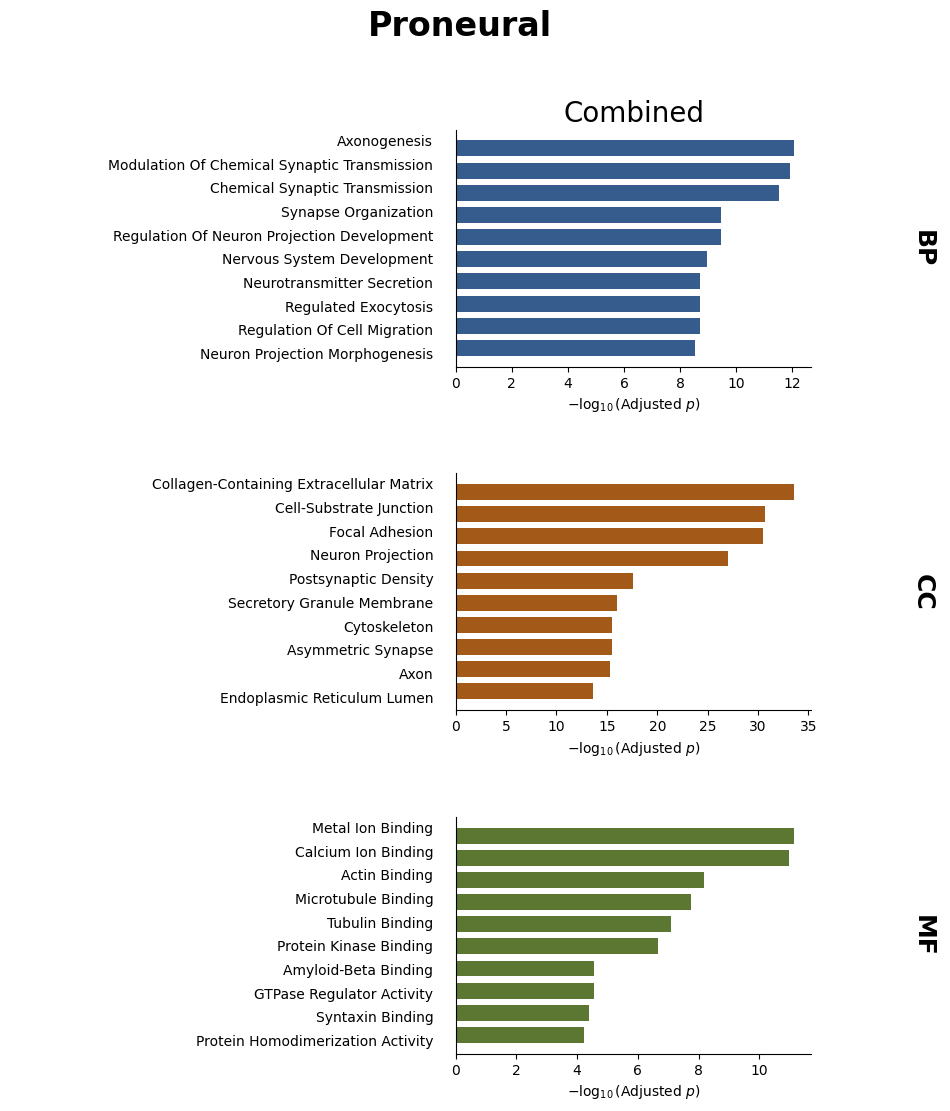


Classical
Significant genes after filtering: 3767
Classical: BP
Classical: CC
Classical: MF


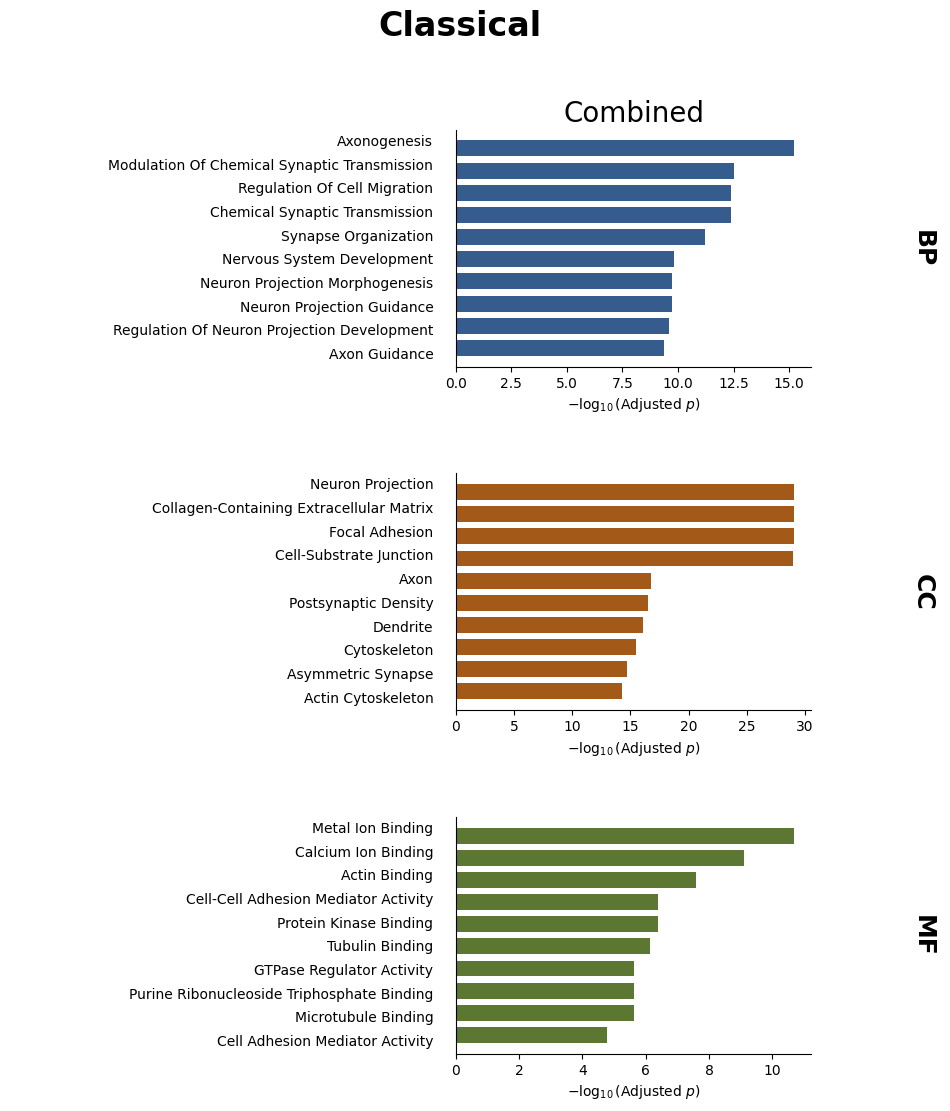


Mesenchymal
Significant genes after filtering: 4071
Mesenchymal: BP
Mesenchymal: CC
Mesenchymal: MF


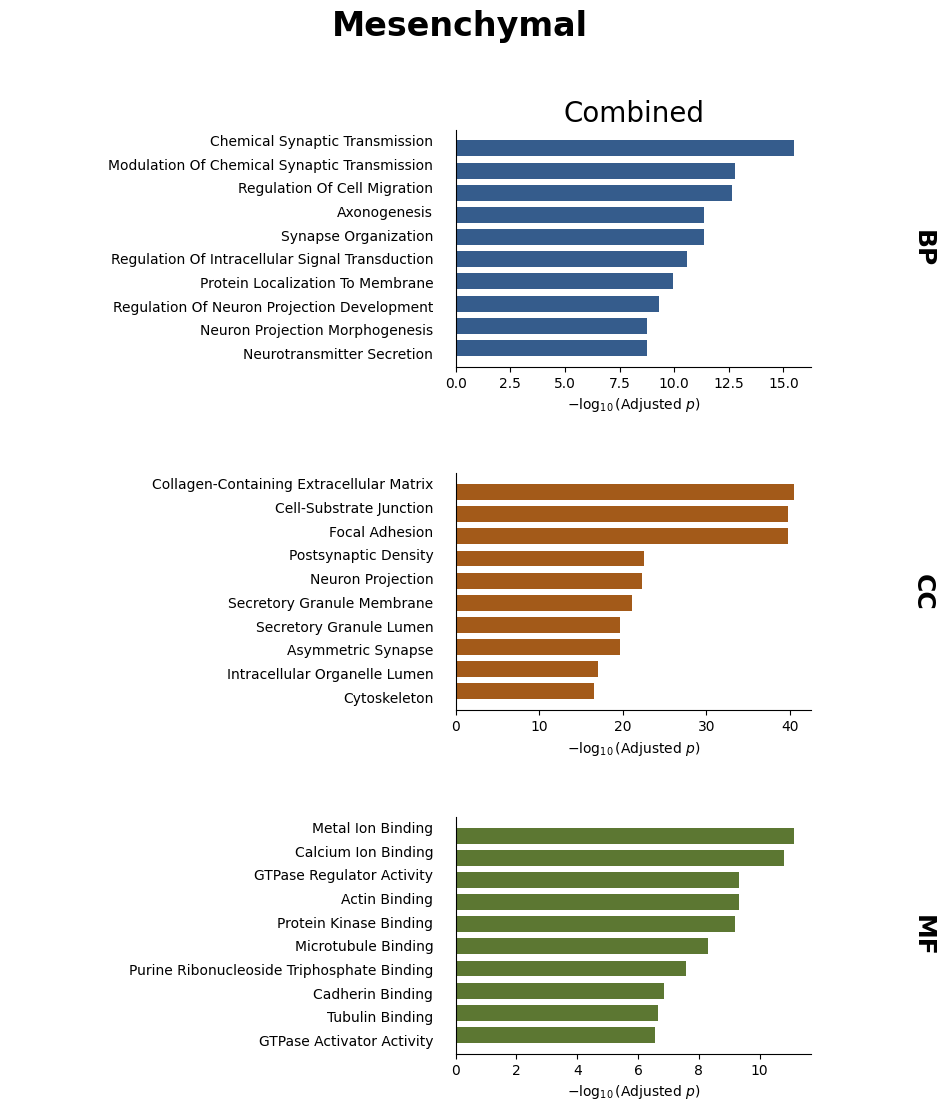

In [2]:
go_combined = {}

for subtype, file in files.items():
    go_combined[subtype] = ge.analyze_subtype(
        file,
        subtype,
        direction="combined"
    )



===== Proneural =====
 Rank                                                                                                  Term  Adjusted P-value
   19                                                              Regulation Of Cell Adhesion (GO:0030155)      9.779470e-08
   33                                                             Collagen Fibril Organization (GO:0030199)      7.697396e-07
   37             Positive Regulation Of Tumor Necrosis Factor Superfamily Cytokine Production (GO:1903557)      1.618768e-06
   38                                             Positive Regulation Of Inflammatory Response (GO:0050729)      2.035691e-06
   49                                                                    Inflammatory Response (GO:0006954)      4.843631e-06
   53                                              Regulation Of Interleukin-1 Beta Production (GO:0032651)      8.926110e-06
   55                                                   Regulation Of Interleukin-6 Production 

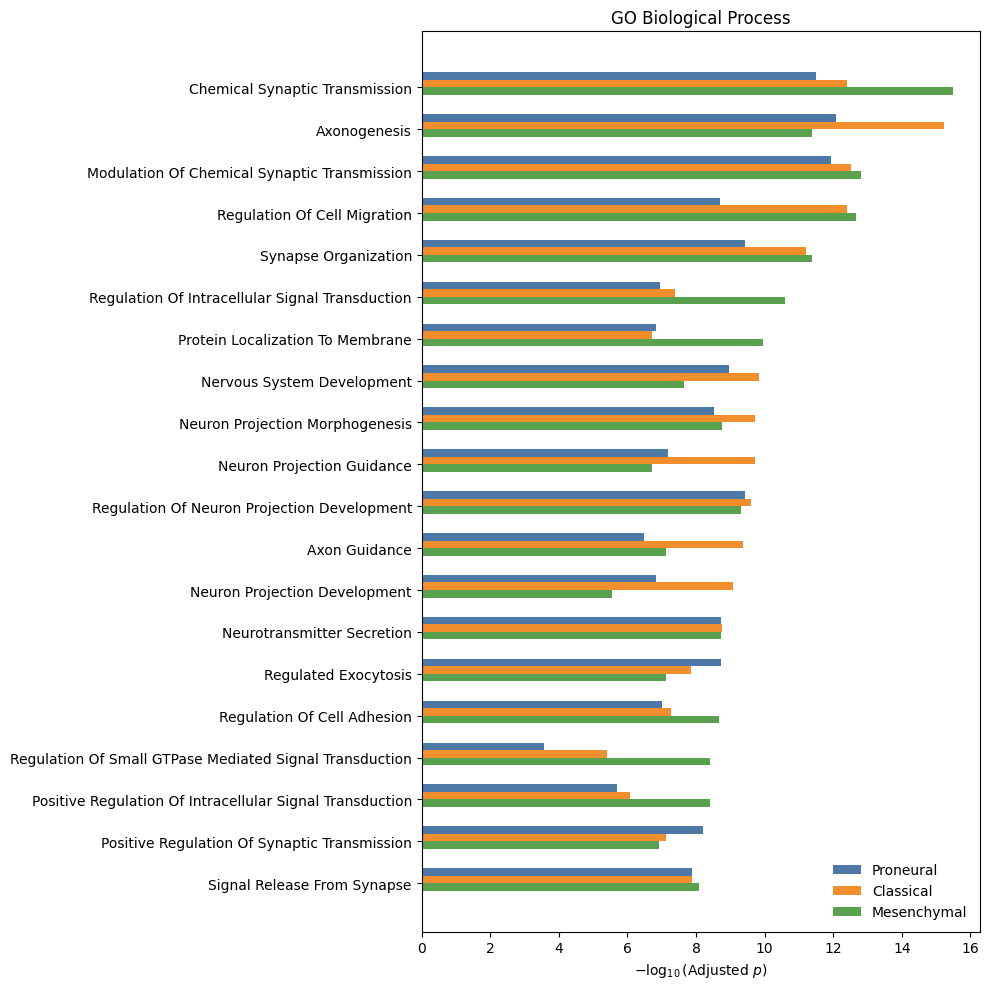

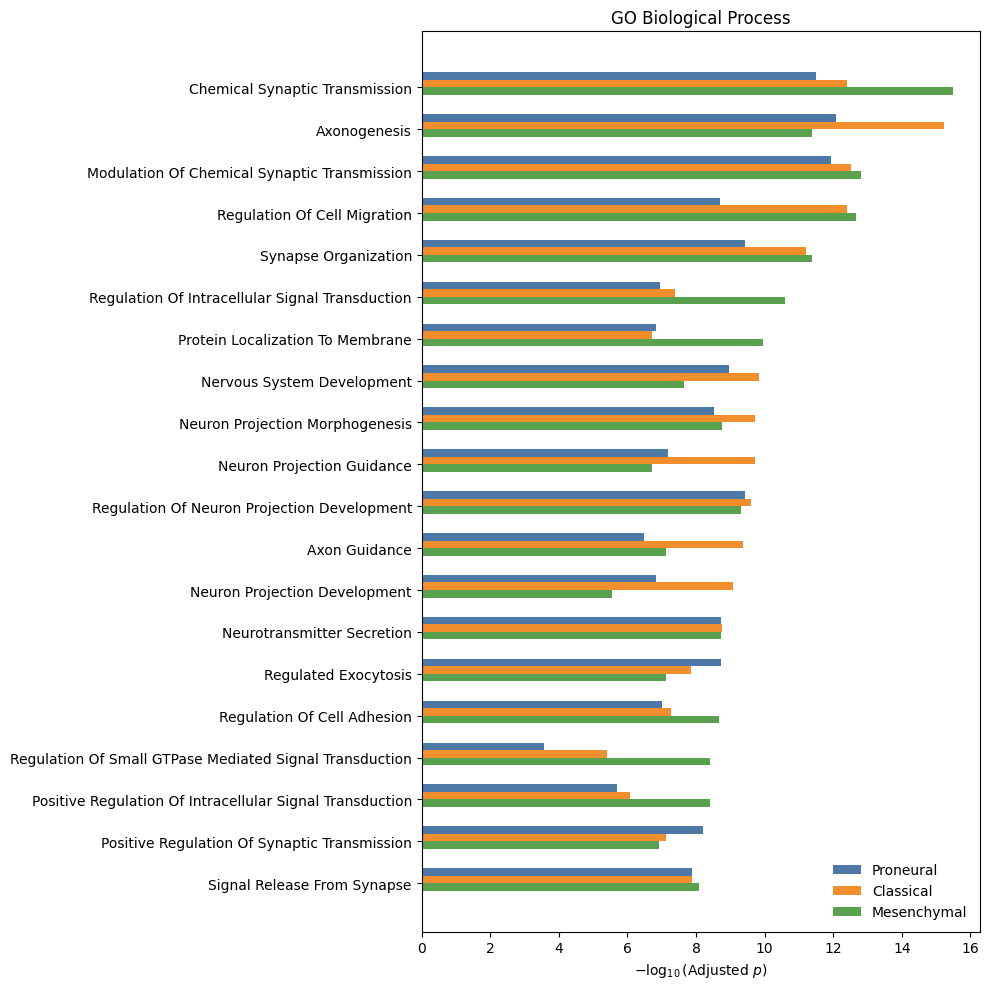

In [3]:

keywords = [
    "immune",
    "inflamm",
    "cytok",
    "interleukin",
    "interferon",
    "leukocyte",
    "lymphocyte",
    "macrophage",
    "chemokine",
    "chemotaxis",
    "extracellular",
    "matrix",
    "collagen",
    "adhesion",
    "wound",
    "angiogenesis",
    "vasculature"
]

pattern = "|".join(keywords)

for subtype in go_combined:

    bp = go_combined[subtype]["BP"].copy()

    bp["Rank"] = range(1, len(bp) + 1)

    hits = bp[
        bp["Term"].str.contains(pattern, case=False, na=False)
    ]

    print(f"\n===== {subtype} =====")

    if hits.empty:
        print("No matching GO terms found.")
    else:
        print(
            hits[["Rank", "Term", "Adjusted P-value"]]
                .to_string(index=False)
        )

# Shared by at least 3 subtypes (recommended)
bp2 = ge.build_go_matrix(go_combined, "BP", n_terms=20, min_subtypes=3)

# Shared by at least 2 subtypes
bp3 = ge.build_go_matrix(go_combined, "BP", n_terms=20, min_subtypes=2)

ge.plot_go_comparison(bp2, "GO Biological Process")
ge.plot_go_comparison(bp3, "GO Biological Process")


In [6]:
mesenchymal_keywords = [
    "immune",
    "inflamm",
    "cytok",
    "interleukin",
    "interferon",
    "leukocyte",
    "lymphocyte",
    "macrophage",
    "chemokine",
    "chemotaxis",
    "extracellular",
    "matrix",
    "collagen",
    "cell adhesion",
    "wound",
    "angiogenesis",
    "vasculature",
    "fibroblast",
    "epithelial",
    "mesenchymal"
]

mesen_pattern = "|".join(mesenchymal_keywords)

mes = go_combined["Mesenchymal"]["BP"].copy()

mes["Rank"] = range(1, len(mes) + 1)

hits_mes = mes[
        mes["Term"].str.contains(mesen_pattern, case=False, na=False)
    ]

print(f"\n===== Mesenchymal =====")

if hits_mes.empty:
    print("No matching GO terms found.")
else:
    print(
        hits_mes[["Rank", "Term", "Adjusted P-value"]]
            .to_string(index=False)
    )



===== Mesenchymal =====
 Rank                                                                                                      Term  Adjusted P-value
   11                                                                  Regulation Of Cell Adhesion (GO:0030155)      2.191577e-09
   16                                                   Positive Regulation Of Cytokine Production (GO:0001819)      1.765843e-08
   19                                                                         Response To Cytokine (GO:0034097)      4.534666e-08
   24                                                                         Cell-Matrix Adhesion (GO:0007160)      1.016677e-07
   25                 Positive Regulation Of Tumor Necrosis Factor Superfamily Cytokine Production (GO:1903557)      1.016677e-07
   42                                                                 Collagen Fibril Organization (GO:0030199)      6.110994e-07
   44                                                 Positive Re

In [7]:
classical_keywords = [
    "cell cycle",
    "cell division",
    "mitotic",
    "DNA replication",
    "DNA repair",
    "chromosome",
    "proliferation",
    "checkpoint",
    "EGFR",
    "growth factor",
    "MAPK",
    "ERK",
    "cell migration",
    "cell motility"
]

clas_pattern = "|".join(classical_keywords)

clas = go_combined["Classical"]["BP"].copy()

clas["Rank"] = range(1, len(clas) + 1)

hits_clas = clas[
        clas["Term"].str.contains(clas_pattern, case=False, na=False)
    ]

print(f"\n===== Classical =====")

if hits_clas.empty:
    print("No matching GO terms found.")
else:
    print(
        hits_clas[["Rank", "Term", "Adjusted P-value"]]
            .to_string(index=False)
    )



===== Classical =====
 Rank                                                                                                       Term  Adjusted P-value
    3                                                                  Regulation Of Cell Migration (GO:0030334)      3.995484e-13
   22                                                         Positive Regulation Of Cell Migration (GO:0030335)      1.108954e-07
   36                                                           Regulation Of ERK1 And ERK2 Cascade (GO:0070372)      3.583929e-06
   52                                                          Positive Regulation Of Cell Motility (GO:2000147)      1.361010e-05
   63                                                         Negative Regulation Of Cell Migration (GO:0030336)      2.530444e-05
   68                                          Positive Regulation Of Cell Population Proliferation (GO:0008284)      3.776415e-05
   75                                                   Cell

In [9]:
proneural_keywords = [
    "neuro",
    "neuron",
    "synap",
    "axon",
    "dendrite",
    "gliogenesis",
    "glial",
    "oligodendro",
    "myelin",
    "nervous system",
    "brain",
    "projection",
    "neurotransmitter",
    "differentiation",
    "development",
    "stem cell",
    "cell fate",
    "forebrain",
    "cerebral",
    "central nervous system"
]

bp = go_combined["Proneural"]["BP"].copy()
bp["Rank"] = range(1, len(bp) + 1)

proneural_hits = bp[
    bp["Term"].str.contains(
        "|".join(proneural_keywords),
        case=False,
        na=False
    )
]

print(proneural_hits[["Rank", "Term", "Adjusted P-value"]].to_string(index=False))

 Rank                                                                                                          Term  Adjusted P-value
    1                                                                                     Axonogenesis (GO:0007409)      8.463008e-13
    2                                                     Modulation Of Chemical Synaptic Transmission (GO:0050804)      1.186011e-12
    3                                                                   Chemical Synaptic Transmission (GO:0007268)      3.091247e-12
    4                                                                             Synapse Organization (GO:0050808)      3.619502e-10
    5                                                      Regulation Of Neuron Projection Development (GO:0010975)      3.619502e-10
    6                                                                       Nervous System Development (GO:0007399)      1.096961e-09
    7                                                         